In [55]:
import sys, os, re, csv, codecs, numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
# from keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.layers import Dense, Input, LSTM, Embedding, Dropout, Activation
from keras.layers import Bidirectional, GlobalMaxPool1D
from keras.models import Model
from keras import initializers, regularizers, constraints, optimizers, layers



In [56]:
train = pd.read_csv('./train_clean.csv')
test = pd.read_csv('./test_clean.csv')
subm = pd.read_csv('./sample_submission.csv')
display(train.shape, train.head())

(7613, 14)

,id,keyword,location,text,target,word_count,unique_word_count,stop_word_count,url_count,mean_word_length,char_count,punctuation_count,hashtag_count,mention_count
0,1,no_keyword,no_location,Our Deeds are the Reason of this #earthquake M...,1,13,13,6,0,4.384615,69,1,1,0
1,4,no_keyword,no_location,Forest fire near La Ronge Sask. Canada,1,7,7,0,0,4.571429,38,1,0,0
2,5,no_keyword,no_location,All residents asked to 'shelter in place' are ...,1,22,20,11,0,5.090909,133,3,0,0
3,6,no_keyword,no_location,"13,000 people receive #wildfires evacuation or...",1,8,8,1,0,7.125000,65,2,1,0
4,7,no_keyword,no_location,Just got sent this photo from Ruby #Alaska as ...,1,16,15,7,0,4.500000,88,2,2,0


In [3]:
list_classes = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
y = train[list_classes].values
list_sentences_train = train["comment_text"]
list_sentences_test = test["comment_text"]



The approach that we are taking is to feed the comments into the LSTM as part of the neural network but we can't just feed the words as it is.

So this is what we are going to do:

- Tokenization - We need to break down the sentence into unique words. For eg, "I love cats and love dogs" will become ["I","love","cats","and","dogs"]
- Indexing - We put the words in a dictionary-like structure and give them an index each For eg, {1:"I",2:"love",3:"cats",4:"and",5:"dogs"}
- Index Representation- We could represent the sequence of words in the comments in the form of index, and feed this chain of index into our LSTM. For eg, [1,2,3,4,2,5]




Fortunately, Keras has made our lives so much easier. If you are using the vanilla Tensorflow, you probably need to implement your own dictionary structure and handle the indexing yourself. In Keras, all the above steps can be done in 4 lines of code. Note that we have to define the number of unique words in our dictionary when tokenizing the sentences.


In [4]:
max_features = 20000
tokenizer = Tokenizer(num_words=max_features)
tokenizer.fit_on_texts(list(list_sentences_train))
list_tokenized_train = tokenizer.texts_to_sequences(list_sentences_train)
list_tokenized_test = tokenizer.texts_to_sequences(list_sentences_test)



You could even look up the occurrence and the index of each words in the dictionary:


In [5]:
#commented it due to long output
#for occurence of words
#tokenizer.word_counts
#for index of words
#tokenizer.word_index



Now, if you look at "list_tokenized_train", you will see that Keras has turned our words into index representation for us


In [6]:
list_tokenized_train[:1]

[[688,
  75,
  1,
  126,
  130,
  177,
  29,
  672,
  4511,
  12052,
  1116,
  86,
  331,
  51,
  2278,
  11448,
  50,
  6864,
  15,
  60,
  2756,
  148,
  7,
  2937,
  34,
  117,
  1221,
  15190,
  2825,
  4,
  45,
  59,
  244,
  1,
  365,
  31,
  1,
  38,
  27,
  143,
  73,
  3462,
  89,
  3085,
  4583,
  2273,
  985]]



But there's still 1 problem! What if some comments are terribly long, while some are just 1 word? Wouldn't our indexed-sentence look like this:

Comment #1: [8,9,3,7,3,6,3,6,3,6,2,3,4,9]

Comment #2: [1,2]

And we have to feed a stream of data that has a consistent length(fixed number of features) isn't it?

And this is why we use "padding"! We could make the shorter sentences as long as the others by filling the shortfall by zeros.But on the other hand, we also have to trim the longer ones to the same length(maxlen) as the short ones. In this case, we have set the max length to be 200.


In [7]:
maxlen = 200
X_t = pad_sequences(list_tokenized_train, maxlen=maxlen)
X_te = pad_sequences(list_tokenized_test, maxlen=maxlen)




How do you know what is the best "maxlen" to set? If you put it too short, you might lose some useful feature that could cost you some accuracy points down the path.If you put it too long, your LSTM cell will have to be larger to store the possible values or states.

One of the ways to go about it is to see the distribution of the number of words in sentences.


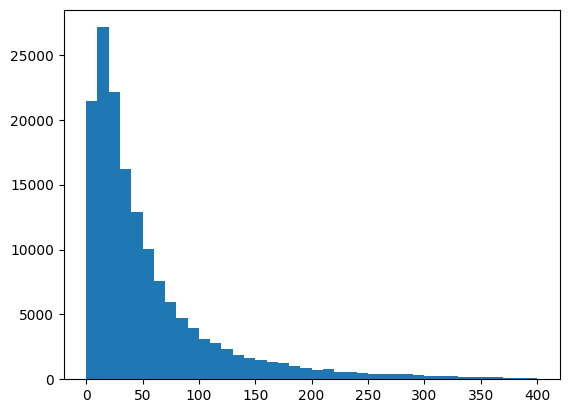

In [8]:
totalNumWords = [len(one_comment) for one_comment in list_tokenized_train]

plt.hist(totalNumWords,bins = np.arange(0,410,10))#[0,50,100,150,200,250,300,350,400])#,450,500,550,600,650,700,750,800,850,900])
plt.show()



As we can see, most of the sentence length is about 30+. We could set the "maxlen" to about 50, but I'm being paranoid so I have set to 200. Then again, it sounds like something you could experiment and see what is the magic number.



**Finally the start of building our model!**

This is the architecture of the model we are trying to build. It's always to good idea to list out the dimensions of each layer in the model to think visually and help you to debug later on. 

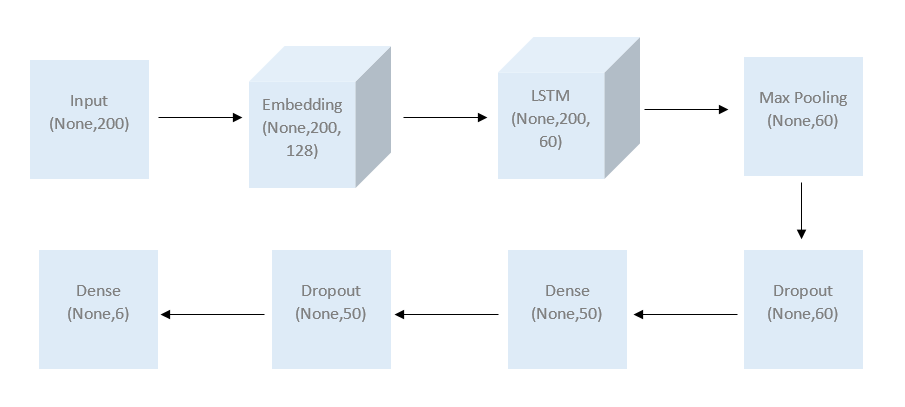

As mentioned earlier, the inputs into our networks are our list of encoded sentences. We begin our defining an Input layer that accepts a list of sentences that has a dimension of 200. 

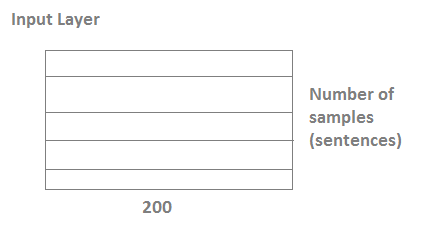

 By indicating an empty space after comma, we are telling Keras to infer the number automatically.

In [9]:
inp = Input(shape=(maxlen, )) #maxlen=200 as defined earlier

Next, we pass it to our Embedding layer, where we project the words to a defined vector space depending on the distance of the surrounding words in a sentence. Embedding allows us to reduce model size and most importantly the huge dimensions we have to deal with, in the case of using one-hot encoding to represent the words in our sentence. 

 The output of the Embedding layer is just a list of the coordinates of the words in this vector space. For eg. (-81.012) for "cat" and (-80.012) for "dog". We could also use the distance of these coordinates to detect relevance and context. Embedding is a pretty deep topic, and if you are interested, this is a comprehensive guide: https://www.analyticsvidhya.com/blog/2017/06/word-embeddings-count-word2veec/



We need to define the size of the "vector space" we have mentioned above, and the number of unique words(max_features) we are using. Again, the embedding size is a parameter that you can tune and experiment.




In [ ]:
embed_size = 128 # tunable
x = Embedding(max_features, embed_size)(inp)



The embedding layer outputs a 3-D tensor of (None, 200, 128). Which is an array of sentence(None means that it's size is inferred), and for each words(200), there is an array of 128 coordinates in the vector space of embedding.




Next, we feed this Tensor into the LSTM layer. We set the LSTM to produce an output that has a dimension of 60 and want it to return the whole unrolled sequence of results. As you probably know, LSTM or RNN works by recursively feeding the output of a previous network into the input of the current network, and you would take the final output after X number of recursion. But depending on use cases, you might want to take the unrolled, or the outputs of each recursion as the result to pass to the next layer. And this is the case.


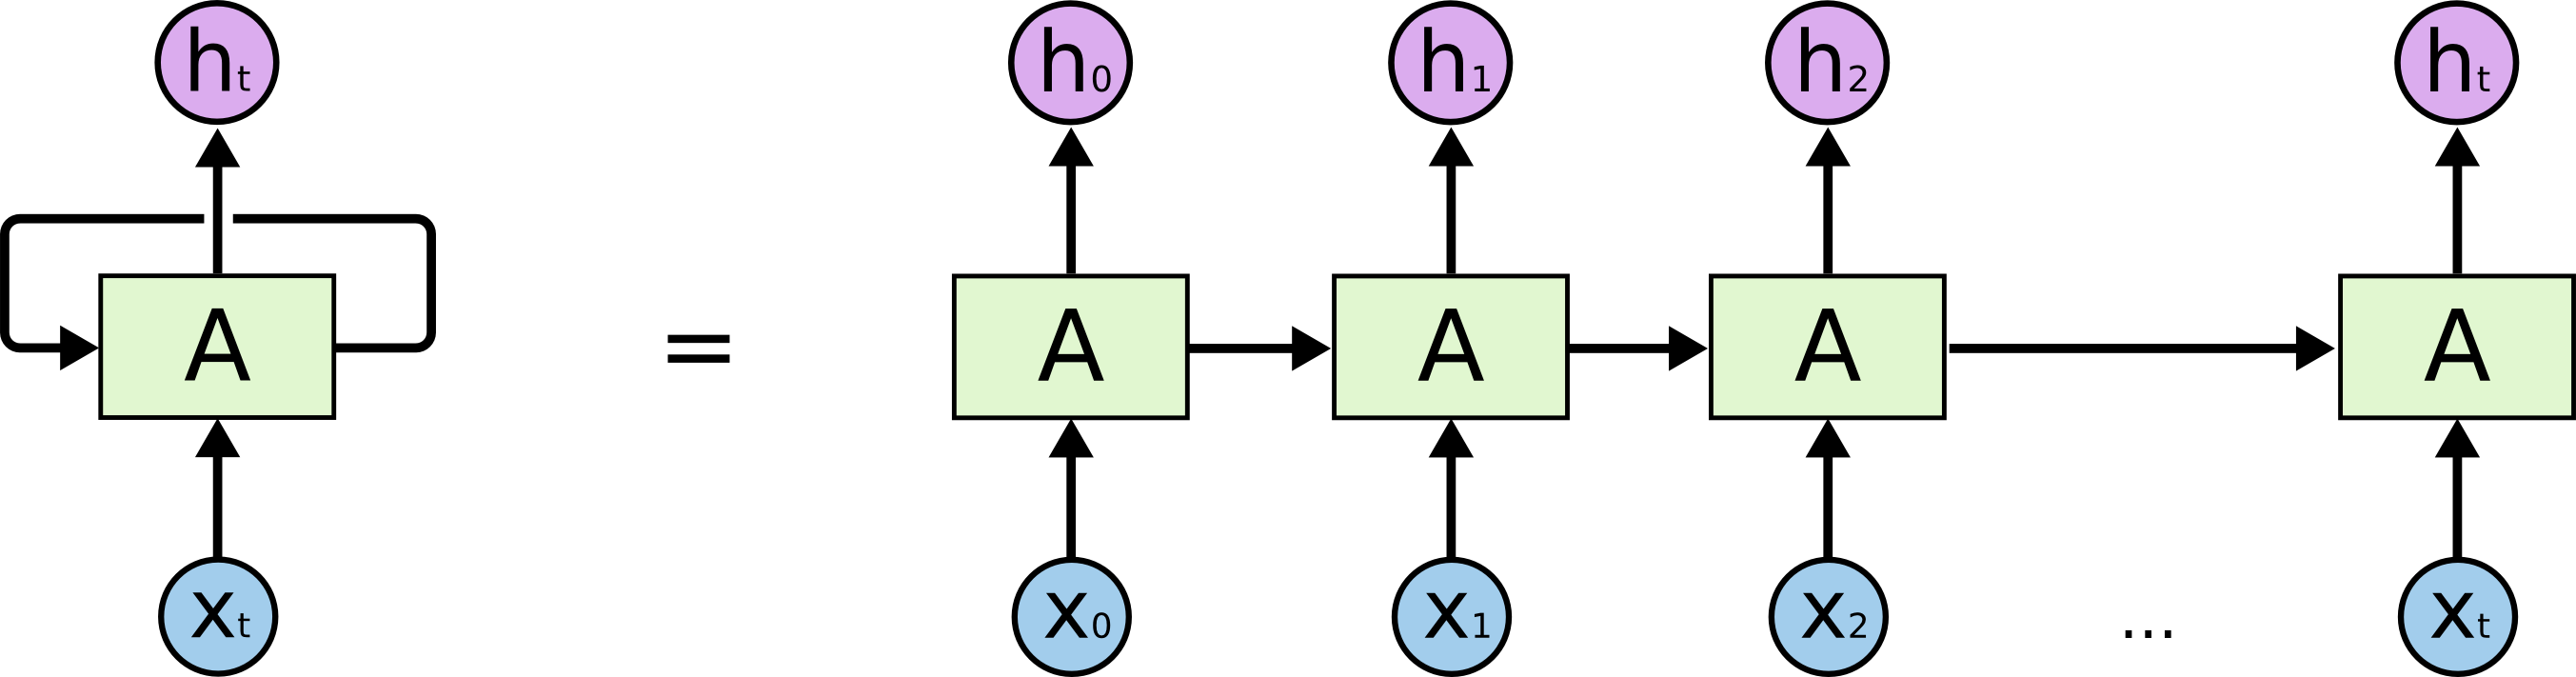



From the above picture, the unrolled LSTM would give us a set of h0,h1,h2 until the last h.

From the short line of code that defines the LSTM layer, it's easy to miss the required input dimensions. LSTM takes in a tensor of [Batch Size, Time Steps, Number of Inputs]. Batch size is the number of samples in a batch, time steps is the number of recursion it runs for each input, or it could be pictured as the number of "A"s in the above picture. Lastly, number of inputs is the number of variables(number of words in each sentence in our case) you pass into LSTM as pictured in "x" above.

We can make use of the output from the previous embedding layer which outputs a 3-D tensor of (None, 200, 128) into the LSTM layer. What it does is going through the samples, recursively run the LSTM model for 200 times, passing in the coordinates of the words each time. And because we want the unrolled version, we will receive a Tensor shape of (None, 200, 60), where 60 is the output dimension we have defined.


In [27]:
x = LSTM(60, return_sequences=True,name='lstm_layer')(x)



Before we could pass the output to a normal layer, we need to reshape the 3D tensor into a 2D one. We reshape carefully to avoid throwing away data that is important to us, and ideally we want the resulting data to be a good representative of the original data.

Therefore, we use a Global Max Pooling layer which is traditionally used in CNN problems to reduce the dimensionality of image data. In simple terms, we go through each patch of data, and we take the maximum values of each patch. These collection of maximum values will be a new set of down-sized data we can use.

As you can see from other Kaggle kernels, different variants (Average,Max,etc) of pooling layers are used for dimensionality reduction and they could yield different results so do try them out.

If you are interested in finding out the technical details of pooling, read up here: https://wiseodd.github.io/techblog/2016/07/18/convnet-maxpool-layer/


In [28]:
x = GlobalMaxPool1D()(x)



With a 2D Tensor in our hands, we pass it to a Dropout layer which indiscriminately "disable" some nodes so that the nodes in the next layer is forced to handle the representation of the missing data and the whole network could result in better generalization.

We set the dropout layer to drop out 10%(0.1) of the nodes.


In [29]:
x = Dropout(0.1)(x)



After a drop out layer, we connect the output of drop out layer to a densely connected layer and the output passes through a RELU function. In short, this is what it does:

Activation( (Input X Weights) + Bias)

all in 1 line, with the weights, bias and activation layer all set up for you! We have defined the Dense layer to produce a output dimension of 50.


In [30]:
x = Dense(50, activation="relu")(x)

In [31]:
x = Dropout(0.1)(x)



Finally, we feed the output into a Sigmoid layer. The reason why sigmoid is used is because we are trying to achieve a binary classification(1,0) for each of the 6 labels, and the sigmoid function will squash the output between the bounds of 0 and 1.


In [32]:
x = Dense(6, activation="sigmoid")(x)



We are almost done! All is left is to define the inputs, outputs and configure the learning process. We have set our model to optimize our loss function using Adam optimizer, define the loss function to be "binary_crossentropy" since we are tackling a binary classification. In case you are looking for the learning rate, the default is set at 0.001.


In [33]:
model = Model(inputs=inp, outputs=x)
model.compile(loss='binary_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])



The moment that we have been waiting for as arrived! It's finally time to put our model to the test. We'll feed in a list of 32 padded, indexed sentence for each batch and split 10% of the data as a validation set. This validation set will be used to assess whether the model has overfitted, for each batch. The model will also run for 2 epochs. These are some of the tunable parameters that you can experiment with, to see if you can push the accurate to the next level without crashing your machine(hence the batch size).


In [34]:
batch_size = 32
epochs = 2
model.fit(X_t,y, batch_size=batch_size, epochs=epochs, validation_split=0.1)

Epoch 1/2
4488/4488 [==============================] - 474s 105ms/step - loss: 0.0689 - accuracy: 0.9403 - val_loss: 0.0494 - val_accuracy: 0.9939
Epoch 2/2
4488/4488 [==============================] - 479s 107ms/step - loss: 0.0451 - accuracy: 0.9794 - val_loss: 0.0469 - val_accuracy: 0.9940


In [35]:
model.save("lstm_toxic_model.h5")

# from tensorflow.keras.models import load_model

# model = load_model("lstm_toxic_model.h5")

/home/ismail/miniconda/envs/tf-dl/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [36]:
# =========================================
# PREDICTIONS
# =========================================
y_test_pred = model.predict(X_te, batch_size=512) # 32 but cpu prefer bigger batches 512

# =========================================
# SUBMISSION
# =========================================
submission = pd.DataFrame({'id': test['id']})
submission[list_classes] = y_test_pred

submission.to_csv('submission_lstm_baseline_keras.csv', index=False)
print("Submission file saved!")

300/300 [==============================] - 57s 188ms/step
Submission file saved!


In [21]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 200)]             0         
                                                                 
 embedding (Embedding)       (None, 200, 128)          2560000   
                                                                 
 lstm_layer (LSTM)           (None, 200, 60)           45360     
                                                                 
 global_max_pooling1d (Glob  (None, 60)                0         
 alMaxPooling1D)                                                 
                                                                 
 dropout (Dropout)           (None, 60)                0         
                                                                 
 dense (Dense)               (None, 50)                3050      
                                                             

 While adding more layers, and doing more fancy transformations, it's a good idea to check if the outputs are performing as you have expected. You can reveal the output of a particular layer by :

In [22]:
from keras import backend as K

# with a Sequential model
get_3rd_layer_output = K.function([model.layers[0].input],
                                  [model.layers[2].output])
layer_output = get_3rd_layer_output([X_t[:1]])[0]
layer_output.shape
#print layer_output to see the actual data

(1, 200, 60)

**Ways to improve:**




- Using Pre-trained models to boost accuracy and take advantage of existing efforts
- Hyper-parameter tuning of bells and whistles
- Introduce early stopping during training of model
- Experiment with different architecture.



# BiLSTM + Conv

In [4]:
import os
from keras.layers import Dense,Input,LSTM,Bidirectional,Activation,Conv1D,GRU
from keras.callbacks import Callback
from keras.layers import Dropout,Embedding,GlobalMaxPooling1D, MaxPooling1D, Add, Flatten
from keras.preprocessing import text, sequence
from keras.layers import GlobalAveragePooling1D, GlobalMaxPooling1D, concatenate, SpatialDropout1D
from keras import initializers, regularizers, constraints, optimizers, layers, callbacks
from keras.callbacks import EarlyStopping,ModelCheckpoint
from keras.models import Model
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

In [5]:
train["comment_text"].fillna("fillna")
test["comment_text"].fillna("fillna")
X_train = train["comment_text"].str.lower()
y_train = train[["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]].values

X_test = test["comment_text"].str.lower()

In [8]:
class RocAucEvaluation(Callback):
    def __init__(self, validation_data=(), interval=1):
        super(Callback, self).__init__()

        self.interval = interval
        self.X_val, self.y_val = validation_data

    def on_epoch_end(self, epoch, logs={}):
        if epoch % self.interval == 0:
            y_pred = self.model.predict(self.X_val, verbose=0)
            score = roc_auc_score(self.y_val, y_pred)
            print("\n ROC-AUC - epoch: {:d} - score: {:.6f}".format(epoch+1, score))



max_features=100000

tok=text.Tokenizer(num_words=max_features,lower=True)
tok.fit_on_texts(list(X_train)+list(X_test))
X_train=tok.texts_to_sequences(X_train)
X_test=tok.texts_to_sequences(X_test)
x_train=sequence.pad_sequences(X_train,maxlen=maxlen)
x_test=sequence.pad_sequences(X_test,maxlen=maxlen)

In [9]:
EMBEDDING_FILE = 'glove.6B.100d.txt'
embeddings_index = {}
with open(EMBEDDING_FILE,encoding='utf8') as f:
    for line in f:
        values = line.rstrip().rsplit(' ')
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs


maxlen=150
embed_size=100

In [10]:
word_index = tok.word_index
#prepare embedding matrix
num_words = min(max_features, len(word_index) + 1)
embedding_matrix = np.zeros((num_words, embed_size))
for word, i in word_index.items():
    if i >= max_features:
        continue
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        # words not found in embedding index will be all-zeros.
        embedding_matrix[i] = embedding_vector

In [11]:
sequence_input = Input(shape=(maxlen, ))
x = Embedding(max_features, embed_size, weights=[embedding_matrix],trainable = False)(sequence_input)
x = SpatialDropout1D(0.2)(x)
x = Bidirectional(GRU(128, return_sequences=True,dropout=0.1,recurrent_dropout=0.1))(x)
x = Conv1D(64, kernel_size = 3, padding = "valid", kernel_initializer = "glorot_uniform")(x)
avg_pool = GlobalAveragePooling1D()(x)
max_pool = GlobalMaxPooling1D()(x)
x = concatenate([avg_pool, max_pool]) 
# x = Dense(128, activation='relu')(x)
# x = Dropout(0.1)(x)
preds = Dense(6, activation="sigmoid")(x)
model = Model(sequence_input, preds)
model.compile(loss='binary_crossentropy',optimizer=Adam(lr=1e-3),metrics=['accuracy'])

2026-04-03 01:55:05.537532: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-03 01:55:05.550475: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [12]:
batch_size = 128
epochs = 4
X_tra, X_val, y_tra, y_val = train_test_split(x_train, y_train, train_size=0.9, random_state=233)

In [15]:




filepath = "./weights_base.best.keras"

checkpoint = ModelCheckpoint(
    filepath,
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    mode='max'
)

early = EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=5
)

callbacks_list = [checkpoint, early]

model.fit(
    X_tra, y_tra,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(X_val, y_val),
    callbacks=callbacks_list,
    verbose=1
)

# Load best weights
model.load_weights(filepath)

print('Predicting....')
y_pred = model.predict(x_test, batch_size=1024, verbose=1)

Epoch 1/4
1122/1122 [==============================] - ETA: 0s - loss: 0.0452 - accuracy: 0.9308
Epoch 1: val_accuracy improved from -inf to 0.97537, saving model to ./weights_base.best.keras
1122/1122 [==============================] - 321s 286ms/step - loss: 0.0452 - accuracy: 0.9308 - val_loss: 0.0465 - val_accuracy: 0.9754
Epoch 2/4
1122/1122 [==============================] - ETA: 0s - loss: 0.0436 - accuracy: 0.9187
Epoch 2: val_accuracy did not improve from 0.97537
1122/1122 [==============================] - 300s 267ms/step - loss: 0.0436 - accuracy: 0.9187 - val_loss: 0.0455 - val_accuracy: 0.8619
Epoch 3/4
1122/1122 [==============================] - ETA: 0s - loss: 0.0422 - accuracy: 0.9150
Epoch 3: val_accuracy did not improve from 0.97537
1122/1122 [==============================] - 296s 264ms/step - loss: 0.0422 - accuracy: 0.9150 - val_loss: 0.0465 - val_accuracy: 0.9374
Epoch 4/4
1122/1122 [==============================] - ETA: 0s - loss: 0.0406 - accuracy: 0.9077
Epoc

In [ ]:
# model.fit(X_tra, y_tra, batch_size=batch_size, epochs=epochs, validation_data=(X_val, y_val),callbacks = callbacks_list,verbose=1)
# #Loading model weights
# model.load_weights(filepath)
# print('Predicting....')
# y_pred = model.predict(x_test,batch_size=1024,verbose=1)

Epoch 1/4
1122/1122 [==============================] - ETA: 0s - loss: 0.0673 - accuracy: 0.9028
 ROC-AUC - epoch: 1 - score: 0.977346


1122/1122 [==============================] - 297s 262ms/step - loss: 0.0673 - accuracy: 0.9028 - val_loss: 0.0536 - val_accuracy: 0.9875
Epoch 2/4
1122/1122 [==============================] - ETA: 0s - loss: 0.0529 - accuracy: 0.9352
 ROC-AUC - epoch: 2 - score: 0.982666


1122/1122 [==============================] - 273s 243ms/step - loss: 0.0529 - accuracy: 0.9352 - val_loss: 0.0491 - val_accuracy: 0.9885
Epoch 3/4
1122/1122 [==============================] - ETA: 0s - loss: 0.0495 - accuracy: 0.9337
 ROC-AUC - epoch: 3 - score: 0.983686


1122/1122 [==============================] - 274s 244ms/step - loss: 0.0495 - accuracy: 0.9337 - val_loss: 0.0478 - val_accuracy: 0.8713
Epoch 4/4
1122/1122 [==============================] - ETA: 0s - loss: 0.0472 - accuracy: 0.9325
 ROC-AUC - epoch: 4 - score: 0.984955


1122/1122 [==============================] - 277s 247ms/step - loss: 0.0472 - accuracy: 0.9325 - val_loss: 0.0471 - val_accuracy: 0.9597


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = './weights_base.best.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [21]:


submission = pd.read_csv('./sample_submission.csv')
submission[["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]] = y_pred
submission.to_csv('submission.csv', index=False)



# CV

Tweets from every keyword group exist in both training and test set and they are from the same sample. In order to replicate the same split technique, StratifiedKFold is used and keyword is passed as y, so stratification is done based on the keyword feature. shuffle is set to True for extra training diversity. Both folds have tweets from every keyword group in training and validation sets which can be seen from below.

In [3]:
from sklearn.model_selection import StratifiedKFold

K = 2
skf = StratifiedKFold(n_splits=K, random_state=42, shuffle=True)


DISASTER = train['target'] == 1
print('Whole Training Set Shape = {}'.format(train.shape))
print('Whole Training Set Unique keyword Count = {}'.format(train['keyword'].nunique()))
print('Whole Training Set Target Rate (Disaster) {}/{} (Not Disaster)'.format(train[DISASTER]['target'].count(), train[~DISASTER]['target'].count()))

# for fold, (trn_idx, val_idx) in enumerate(skf.split(train['text_cleaned'], train['target']), 1):
#     print('\nFold {} Training Set Shape = {} - Validation Set Shape = {}'.format(fold, train.loc[trn_idx, 'text_cleaned'].shape, train.loc[val_idx, 'text_cleaned'].shape))
#     print('Fold {} Training Set Unique keyword Count = {} - Validation Set Unique keyword Count = {}'.format(fold, train.loc[trn_idx, 'keyword'].nunique(), train.loc[val_idx, 'keyword'].nunique()))   

for fold, (trn_idx, val_idx) in enumerate(skf.split(train['text'], train['target']), 1):
    print('\nFold {} Training Set Shape = {} - Validation Set Shape = {}'.format(fold, train.loc[trn_idx, 'text'].shape, train.loc[val_idx, 'text'].shape))
    print('Fold {} Training Set Unique keyword Count = {} - Validation Set Unique keyword Count = {}'.format(fold, train.loc[trn_idx, 'keyword'].nunique(), train.loc[val_idx, 'keyword'].nunique()))   

Whole Training Set Shape = (7613, 14)
Whole Training Set Unique keyword Count = 222
Whole Training Set Target Rate (Disaster) 3271/4342 (Not Disaster)

Fold 1 Training Set Shape = (3806,) - Validation Set Shape = (3807,)
Fold 1 Training Set Unique keyword Count = 222 - Validation Set Unique keyword Count = 222

Fold 2 Training Set Shape = (3807,) - Validation Set Shape = (3806,)
Fold 2 Training Set Unique keyword Count = 222 - Validation Set Unique keyword Count = 222


**Metric: Mean F1-score / Macro Avg F1**

The leaderboard is based on Mean F-Score which can be implemented with Macro Average F1 Score. However, it won't be very informative without Accuracy, Precision and Recall because classes are almost balanced and it is hard to tell which class is harder to predict.

- Accuracy measures the fraction of the total sample that is correctly identified
- Precision measures that out of all the examples predicted as positive, how many are actually positive
- Recall measures that out of all the actual positives, how many examples were correctly classified as positive by the model
- F1 Score is the harmonic mean of the Precision and Recall

Keras has accuracy in its metrics module, but doesn't have rest of the metrics stated above. Another crucial point is Precision, Recall and F1-Score are global metrics so they should be calculated on whole training or validation set. Computing them on every batch would be both misleading and ineffective in terms of execution time. ClassificationReport which is similar to sklearn.metrics.classification_report, computes those metrics after every epoch for the given training and validation set.

In [4]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score
from keras.callbacks import Callback

class ClassificationReport(Callback):
    
    def __init__(self, train_data=(), validation_data=()):
        super(Callback, self).__init__()
        
        self.X_train, self.y_train = train_data
        self.train_precision_scores = []
        self.train_recall_scores = []
        self.train_f1_scores = []
        
        self.X_val, self.y_val = validation_data
        self.val_precision_scores = []
        self.val_recall_scores = []
        self.val_f1_scores = [] 
               
    def on_epoch_end(self, epoch, logs={}):
        train_predictions = np.round(self.model.predict(self.X_train, verbose=0))        
        train_precision = precision_score(self.y_train, train_predictions, average='macro')
        train_recall = recall_score(self.y_train, train_predictions, average='macro')
        train_f1 = f1_score(self.y_train, train_predictions, average='macro')
        self.train_precision_scores.append(train_precision)        
        self.train_recall_scores.append(train_recall)
        self.train_f1_scores.append(train_f1)
        
        val_predictions = np.round(self.model.predict(self.X_val, verbose=0))
        val_precision = precision_score(self.y_val, val_predictions, average='macro')
        val_recall = recall_score(self.y_val, val_predictions, average='macro')
        val_f1 = f1_score(self.y_val, val_predictions, average='macro')
        self.val_precision_scores.append(val_precision)        
        self.val_recall_scores.append(val_recall)        
        self.val_f1_scores.append(val_f1)
        
        print('\nEpoch: {} - Training Precision: {:.6} - Training Recall: {:.6} - Training F1: {:.6}'.format(epoch + 1, train_precision, train_recall, train_f1))
        print('Epoch: {} - Validation Precision: {:.6} - Validation Recall: {:.6} - Validation F1: {:.6}'.format(epoch + 1, val_precision, val_recall, val_f1))  

# BERT Layer


This model uses the implementation of BERT from the TensorFlow Models repository on GitHub at tensorflow/models/official/nlp/bert. It uses L=12 hidden layers (Transformer blocks), a hidden size of H=768, and A=12 attention heads.

This model has been pre-trained for English on the Wikipedia and BooksCorpus. Inputs have been "uncased", meaning that the text has been lower-cased before tokenization into word pieces, and any accent markers have been stripped. In order to download this model, Internet must be activated on the kernel.


In [9]:
import tensorflow_hub as hub
# bert_layer = hub.KerasLayer('https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/1', trainable=True)

bert_layer = hub.KerasLayer('https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/1', trainable=True)


ModuleNotFoundError: No module named 'keras.api'

In [16]:
from transformers import BertTokenizer, TFBertModel
import tensorflow as tf
import numpy as np

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = TFBertModel.from_pretrained("bert-base-uncased")

def encode_texts(texts, max_seq_length=128):
    encodings = tokenizer(
        texts,
        padding="max_length",
        truncation=True,
        max_length=max_seq_length,
        return_tensors="tf"
    )
    return encodings['input_ids'], encodings['attention_mask'], encodings['token_type_ids']

texts = ["This is a disaster tweet"]
tokens, masks, segments = encode_texts(texts)

outputs = model(tokens, attention_mask=masks, token_type_ids=segments)
pooled_output = outputs.pooler_output
print(pooled_output.shape)  # [batch_size, 768]

/home/ismail/miniconda/envs/tf-dl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


ImportError: cannot import name 'TFBertModel' from 'transformers' (/home/ismail/miniconda/envs/tf-dl/lib/python3.10/site-packages/transformers/__init__.py)

**Architecture**

DisasterDetector is a wrapper that incorporates the cross-validation and metrics stated above.

The tokenization of input text is performed with the FullTokenizer class from tensorflow/models/official/nlp/bert/tokenization.py. max_seq_length parameter can be used for tuning the sequence length of text.

Parameters such as lr, epochs and batch_size can be used for controlling the learning process. There are no dense or pooling layers added after last layer of BERT. SGD is used as optimizer since others have hard time while converging.

plot_learning_curve plots Accuracy, Precision, Recall and F1 Score (for validation set) stored after every epoch alongside with training/validation loss curve. This helps to see which metric fluctuates most while training.

In [ ]:
import tensorflow_hub as hub

class DisasterDetector:
    
    def __init__(self, bert_layer, max_seq_length=128, lr=0.0001, epochs=15, batch_size=32):
        
        # BERT and Tokenization params
        self.bert_layer = bert_layer
        
        self.max_seq_length = max_seq_length        
        vocab_file = self.bert_layer.resolved_object.vocab_file.asset_path.numpy()
        do_lower_case = self.bert_layer.resolved_object.do_lower_case.numpy()
        self.tokenizer = tokenization.FullTokenizer(vocab_file, do_lower_case)
        
        # Learning control params
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        
        self.models = []
        self.scores = {}
        
        
    def encode(self, texts):
                
        all_tokens = []
        all_masks = []
        all_segments = []

        for text in texts:
            text = self.tokenizer.tokenize(text)
            text = text[:self.max_seq_length - 2]
            input_sequence = ['[CLS]'] + text + ['[SEP]']
            pad_len = self.max_seq_length - len(input_sequence)

            tokens = self.tokenizer.convert_tokens_to_ids(input_sequence)
            tokens += [0] * pad_len
            pad_masks = [1] * len(input_sequence) + [0] * pad_len
            segment_ids = [0] * self.max_seq_length

            all_tokens.append(tokens)
            all_masks.append(pad_masks)
            all_segments.append(segment_ids)

        return np.array(all_tokens), np.array(all_masks), np.array(all_segments)
    
    
    def build_model(self):
        
        input_word_ids = Input(shape=(self.max_seq_length,), dtype=tf.int32, name='input_word_ids')
        input_mask = Input(shape=(self.max_seq_length,), dtype=tf.int32, name='input_mask')
        segment_ids = Input(shape=(self.max_seq_length,), dtype=tf.int32, name='segment_ids')    
        
        pooled_output, sequence_output = self.bert_layer([input_word_ids, input_mask, segment_ids])   
        clf_output = sequence_output[:, 0, :]
        out = Dense(1, activation='sigmoid')(clf_output)
        
        model = Model(inputs=[input_word_ids, input_mask, segment_ids], outputs=out)
        optimizer = SGD(learning_rate=self.lr, momentum=0.8)
        model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
        
        return model
    
    
    def train(self, X):
        
        for fold, (trn_idx, val_idx) in enumerate(skf.split(X['text_cleaned'], X['keyword'])):
            
            print('\nFold {}\n'.format(fold))
        
            X_trn_encoded = self.encode(X.loc[trn_idx, 'text_cleaned'].str.lower())
            y_trn = X.loc[trn_idx, 'target_relabeled']
            X_val_encoded = self.encode(X.loc[val_idx, 'text_cleaned'].str.lower())
            y_val = X.loc[val_idx, 'target_relabeled']
        
            # Callbacks
            metrics = ClassificationReport(train_data=(X_trn_encoded, y_trn), validation_data=(X_val_encoded, y_val))
            
            # Model
            model = self.build_model()        
            model.fit(X_trn_encoded, y_trn, validation_data=(X_val_encoded, y_val), callbacks=[metrics], epochs=self.epochs, batch_size=self.batch_size)
            
            self.models.append(model)
            self.scores[fold] = {
                'train': {
                    'precision': metrics.train_precision_scores,
                    'recall': metrics.train_recall_scores,
                    'f1': metrics.train_f1_scores                    
                },
                'validation': {
                    'precision': metrics.val_precision_scores,
                    'recall': metrics.val_recall_scores,
                    'f1': metrics.val_f1_scores                    
                }
            }
                    
                
    def plot_learning_curve(self):
        
        fig, axes = plt.subplots(nrows=K, ncols=2, figsize=(20, K * 6), dpi=100)
    
        for i in range(K):
            
            # Classification Report curve
            sns.lineplot(x=np.arange(1, self.epochs + 1), y=clf.models[i].history.history['val_accuracy'], ax=axes[i][0], label='val_accuracy')
            sns.lineplot(x=np.arange(1, self.epochs + 1), y=clf.scores[i]['validation']['precision'], ax=axes[i][0], label='val_precision')
            sns.lineplot(x=np.arange(1, self.epochs + 1), y=clf.scores[i]['validation']['recall'], ax=axes[i][0], label='val_recall')
            sns.lineplot(x=np.arange(1, self.epochs + 1), y=clf.scores[i]['validation']['f1'], ax=axes[i][0], label='val_f1')        

            axes[i][0].legend() 
            axes[i][0].set_title('Fold {} Validation Classification Report'.format(i), fontsize=14)

            # Loss curve
            sns.lineplot(x=np.arange(1, self.epochs + 1), y=clf.models[0].history.history['loss'], ax=axes[i][1], label='train_loss')
            sns.lineplot(x=np.arange(1, self.epochs + 1), y=clf.models[0].history.history['val_loss'], ax=axes[i][1], label='val_loss')

            axes[i][1].legend() 
            axes[i][1].set_title('Fold {} Train / Validation Loss'.format(i), fontsize=14)

            for j in range(2):
                axes[i][j].set_xlabel('Epoch', size=12)
                axes[i][j].tick_params(axis='x', labelsize=12)
                axes[i][j].tick_params(axis='y', labelsize=12)

        plt.show()
        
        
    def predict(self, X):
        
        X_test_encoded = self.encode(X['text_cleaned'].str.lower())
        y_pred = np.zeros((X_test_encoded[0].shape[0], 1))

        for model in self.models:
            y_pred += model.predict(X_test_encoded) / len(self.models)

        return y_pred


**basic LSTM with GloVe**

In [ ]:
import numpy as np
import pandas as pd
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from tqdm import tqdm
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D
from tensorflow.keras.initializers import Constant
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import nltk

# --- NLTK setup ---
nltk.download('punkt')
nltk.download('stopwords')
stop = set(stopwords.words('english'))

# --- Parameters ---
MAX_LEN = 40
EMBEDDING_DIM = 100
GLOVE_PATH = './glove.6B.100d.txt'

# --- Preprocessing function ---
def preprocess_texts(texts):
    corpus = []
    for text in tqdm(texts, desc="Processing texts"):
        words = [w.lower() for w in word_tokenize(text) if w.isalpha() and w.lower() not in stop]
        corpus.append(words)
    return corpus

# --- Create corpus ---
train_corpus = preprocess_texts(train['text'])
test_corpus = preprocess_texts(test['text'])

# --- Tokenizer ---
tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_corpus + test_corpus)  # fit on all texts
word_index = tokenizer.word_index
num_words = len(word_index) + 1

# --- Convert to sequences & pad ---
train_seq = pad_sequences(tokenizer.texts_to_sequences(train_corpus), maxlen=MAX_LEN, padding='post', truncating='post')
test_seq = pad_sequences(tokenizer.texts_to_sequences(test_corpus), maxlen=MAX_LEN, padding='post', truncating='post')

# --- Load GloVe embeddings ---
embedding_index = {}
with open(GLOVE_PATH, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = vector

# --- Build embedding matrix ---
embedding_matrix = np.zeros((num_words, EMBEDDING_DIM))
for word, i in word_index.items():
    vec = embedding_index.get(word)
    if vec is not None:
        embedding_matrix[i] = vec

# --- Train/validation split ---
X_train, X_val, y_train, y_val = train_test_split(train_seq, train['target'].values, test_size=0.15, random_state=42)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

# --- Build model ---
model = Sequential()
model.add(Embedding(num_words, EMBEDDING_DIM,
                    embeddings_initializer=Constant(embedding_matrix),
                    input_length=MAX_LEN,
                    trainable=False))
model.add(SpatialDropout1D(0.2))
model.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(1, activation='sigmoid'))

optimizer = Adam(learning_rate=1e-5)
model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

model.summary()



# --- Train the model ---
history = model.fit(X_train, y_train, batch_size=4, epochs=15,
                    validation_data=(X_val, y_val), verbose=2)

# --- Predict on test ---
y_pred = model.predict(test_seq, verbose=0)
y_pred = np.round(y_pred).astype(int).reshape(-1)  # flatten to 1D

# --- Prepare submission ---
sample_sub = pd.read_csv('../input/nlp-getting-started/sample_submission.csv')
submission = pd.DataFrame({'id': sample_sub['id'].values, 'target': y_pred})
submission.to_csv('submission.csv', index=False)

print("Submission saved as submission.csv")

[nltk_data] Downloading package punkt to /home/ismail/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/ismail/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
Processing texts: 100%|██████████| 3263/3263 [00:00<00:00, 10918.30it/s]


X_train shape: (6471, 40)
X_val shape: (1142, 40)


/home/ismail/miniconda/envs/tf-dl/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1618/1618 - 26s - 16ms/step - accuracy: 0.5673 - loss: 0.6915 - val_accuracy: 0.5701 - val_loss: 0.6896
Epoch 2/15
1618/1618 - 21s - 13ms/step - accuracy: 0.5704 - loss: 0.6868 - val_accuracy: 0.5701 - val_loss: 0.6809
Epoch 3/15
1618/1618 - 20s - 12ms/step - accuracy: 0.6439 - loss: 0.6376 - val_accuracy: 0.7627 - val_loss: 0.5481
Epoch 4/15
1618/1618 - 19s - 12ms/step - accuracy: 0.7282 - loss: 0.5640 - val_accuracy: 0.7697 - val_loss: 0.5145
Epoch 5/15
1618/1618 - 20s - 13ms/step - accuracy: 0.7350 - loss: 0.5582 - val_accuracy: 0.7732 - val_loss: 0.5024
Epoch 6/15
1618/1618 - 22s - 14ms/step - accuracy: 0.7435 - loss: 0.5520 - val_accuracy: 0.7793 - val_loss: 0.4941
Epoch 7/15


(7613, 14)

**similar to LSTM baseline but for pytorch**

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import re
import random

# ===========================
# 1️⃣ Fix seeds for reproducibility
# ===========================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ===========================
# 2️⃣ Load data
# ===========================
train = pd.read_csv('./train_clean.csv')
test = pd.read_csv('./test_clean.csv')
list_classes = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

y = train[list_classes].values
list_sentences_train = train["comment_text"].fillna("").values
list_sentences_test = test["comment_text"].fillna("").values

# ===========================
# 3️⃣ Simple PyTorch tokenizer
# ===========================
max_features = 20000
maxlen = 200

# Build vocabulary
def simple_tokenizer(sentences, max_features):
    word_count = {}
    for text in sentences:
        for word in re.findall(r'\w+', text.lower()):
            word_count[word] = word_count.get(word, 0) + 1
    vocab = sorted(word_count, key=word_count.get, reverse=True)[:max_features-2]
    word2idx = {word: idx+2 for idx, word in enumerate(vocab)}
    word2idx["<PAD>"] = 0
    word2idx["<UNK>"] = 1
    return word2idx

word2idx = simple_tokenizer(list_sentences_train, max_features)


def encode_sentences(sentences, word2idx, maxlen):
    sequences = []
    for text in sentences:
        # seq = [word2idx.get(w, 1) for w in re.findall(r'\w+', text.lower())]
        seq = [word2idx.get(w, 0) for w in re.findall(r'\w+', text.lower())]  # unknown -> PAD
        if len(seq) < maxlen:
            seq = seq + [0]*(maxlen-len(seq))
        else:
            seq = seq[:maxlen]
        sequences.append(seq)
    return np.array(sequences)

X_t = encode_sentences(list_sentences_train, word2idx, maxlen)
X_te = encode_sentences(list_sentences_test, word2idx, maxlen)

# ===========================
# 4️⃣ Dataset & DataLoader
# ===========================
class CommentDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32) if y is not None else None
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        if self.y is not None:
            return self.X[idx], self.y[idx]
        else:
            return self.X[idx]

train_dataset = CommentDataset(X_t, y)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = CommentDataset(X_te)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# ===========================
# 5️⃣ LSTM Model
# ===========================
class LSTMBaseline(nn.Module):
    def __init__(self, vocab_size, embed_size, maxlen):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.lstm = nn.LSTM(embed_size, 60, batch_first=True)
        self.dropout1 = nn.Dropout(0.1)
        self.fc1 = nn.Linear(60, 50)
        self.dropout2 = nn.Dropout(0.1)
        self.fc2 = nn.Linear(50, 6)
        
    def forward(self, x):
        x = self.embedding(x)
        x, _ = self.lstm(x)
        x, _ = torch.max(x, dim=1)  # GlobalMaxPool1D
        x = self.dropout1(x)
        x = torch.relu(self.fc1(x))
        x = self.dropout2(x)
        x = torch.sigmoid(self.fc2(x))
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMBaseline(vocab_size=len(word2idx), embed_size=300, maxlen=maxlen).to(device)
nn.init.uniform_(model.embedding.weight, -0.05, 0.05)

for names in model.lstm._all_weights:
    for name in names:
        if 'bias' in name:
            bias = getattr(model.lstm, name)
            n = bias.size(0)
            # forget gate is the 2nd quarter
            bias.data[n//4:n//2].fill_(1.0)
# ===========================
# 6️⃣ Loss & Optimizer
# ===========================
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ===========================
# 7️⃣ Training
# ===========================
epochs = 2
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss/len(train_loader):.4f}")

# ===========================
# 8️⃣ Predict & save submission
# ===========================
model.eval()
preds = []
with torch.no_grad():
    for xb in test_loader:
        xb = xb.to(device)
        preds.append(model(xb).cpu())
y_test_pred = torch.cat(preds, dim=0).numpy()

submission = pd.DataFrame({'id': test['id']})
submission[list_classes] = y_test_pred
submission.to_csv('submission_lstm_pytorch_only.csv', index=False)
print("Submission file saved!")